In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Conv1D, GlobalMaxPooling1D, Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import seaborn as sns

In [2]:
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)


#Read The Data and windowing become per minute

In [3]:
def read_gate_toll_data(file_path, sheet="BI"):
    df = pd.read_excel(file_path, sheet_name=sheet, header=None, usecols="A:F")

    df.columns = ["Lane_A","Lane_B","Lane_C","Lane_D","Lane_E","Lane_F"]

    df = df.apply(lambda col: pd.to_datetime(col, unit="s", errors="coerce"))

    df_long = df.melt(var_name="Lane", value_name="Entry_Time").dropna()

    return df_long


def create_minute_counts(data):
    data = data.sort_values(["Lane", "Entry_Time"])
    data["Minute_Window"] = data["Entry_Time"].dt.floor("min")

    return (
        data.groupby(["Lane", "Minute_Window"])
        .size()
        .reset_index(name="Vehicle_Count")
    )


def fill_missing_minutes_per_lane(df):
    df["Minute_Window"] = pd.to_datetime(df["Minute_Window"])
    full_data = []

    for lane in df["Lane"].unique():
        lane_df = df[df["Lane"] == lane].copy()
        lane_df = lane_df.set_index("Minute_Window")

        full_range = pd.date_range(
            start=lane_df.index.min().floor("H"),
            periods=60,
            freq="1min"
        )

        lane_df = lane_df.reindex(full_range, fill_value=0)
        lane_df.index.name = "Minute_Window"
        lane_df = lane_df.reset_index()
        lane_df["Lane"] = lane

        full_data.append(lane_df)

    return pd.concat(full_data, ignore_index=True)


#create features from previous data

In [4]:
def create_features(df):
    df = df.sort_values(["Lane", "Minute_Window"]).copy()

    df["Delta"] = (
        df.groupby("Lane")["Vehicle_Count"]
        .diff()
        .fillna(0)
    )

    df["Rolling_Mean_3"] = (
        df.groupby("Lane")["Vehicle_Count"]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df["Rolling_Mean_5"] = (
        df.groupby("Lane")["Vehicle_Count"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    return df

#Create label based on 50% percentile, 50%=3

In [5]:
def create_high_low_label(df, percentile=50):
    df = df.sort_values(["Lane", "Minute_Window"]).copy()

    thresholds = (
        df.groupby("Lane")["Vehicle_Count"]
        .quantile(percentile / 100.0)
        .to_dict()
    )

    print(f"\nThresholds (percentile={percentile}):")
    for lane, value in thresholds.items():
        print(f"Lane {lane}: {value}")

    df["Traffic_Label"] = df.apply(
        lambda row: 1 if row["Vehicle_Count"] > thresholds[row["Lane"]] else 0,
        axis=1
    )

    return df

In [6]:
def create_sequences_per_lane(df, feature_cols, target_col, seq_length):
    X, y = [], []

    for lane in df["Lane"].unique():
        lane_df = df[df["Lane"] == lane].sort_values("Minute_Window")

        for i in range(len(lane_df) - seq_length):
            X.append(lane_df[feature_cols].iloc[i:i+seq_length].values)
            y.append(lane_df[target_col].iloc[i+seq_length])

    return np.array(X), np.array(y)


In [7]:
file_path = r"C:\Users\BI2026\Dataset\data tol.xlsx"

data = read_gate_toll_data(file_path)
windowed_counts = create_minute_counts(data)
lane_counts = fill_missing_minutes_per_lane(windowed_counts)
lane_counts = create_high_low_label(lane_counts, percentile=50)
lane_counts = create_features(lane_counts)

# Save for Streamlit
lane_counts.to_csv(
    r"C:\Users\BI2026\Dataset\lane_counts.csv",
    index=False
)



Thresholds (percentile=50):
Lane Lane_A: 3.0
Lane Lane_B: 3.0
Lane Lane_C: 3.0
Lane Lane_D: 3.0
Lane Lane_E: 3.0
Lane Lane_F: 3.0


C:\Users\kevin\AppData\Local\Temp\ipykernel_9752\3741859878.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start=lane_df.index.min().floor("H"),
C:\Users\kevin\AppData\Local\Temp\ipykernel_9752\3741859878.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start=lane_df.index.min().floor("H"),
C:\Users\kevin\AppData\Local\Temp\ipykernel_9752\3741859878.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start=lane_df.index.min().floor("H"),
C:\Users\kevin\AppData\Local\Temp\ipykernel_9752\3741859878.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start=lane_df.index.min().floor("H"),
C:\Users\kevin\AppData\Local\Temp\ipykernel_9752\3741859878.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start=lane_df

#lane pattern analysis

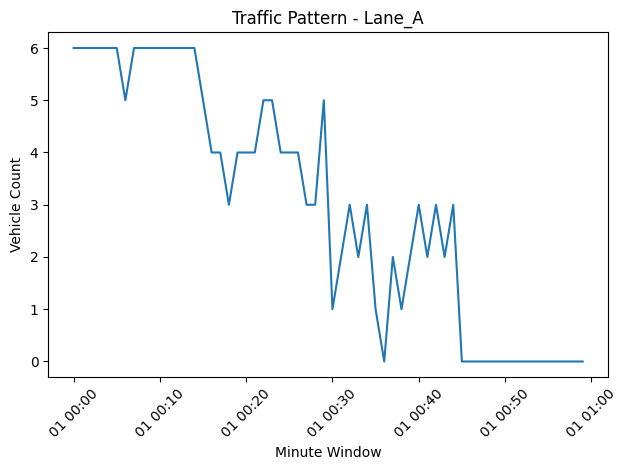

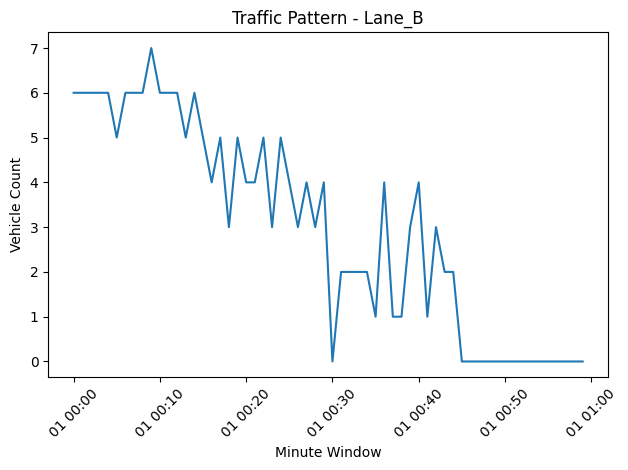

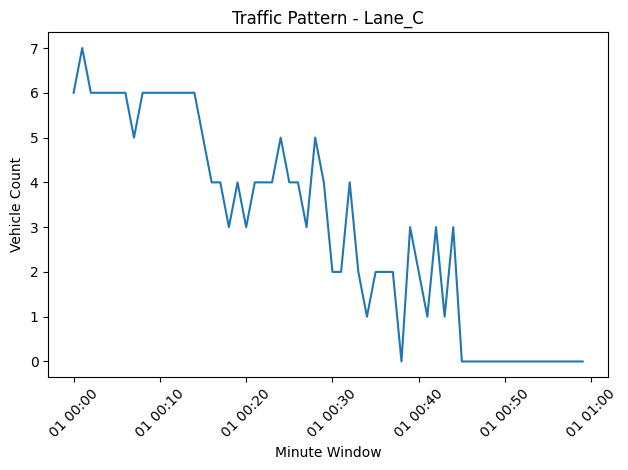

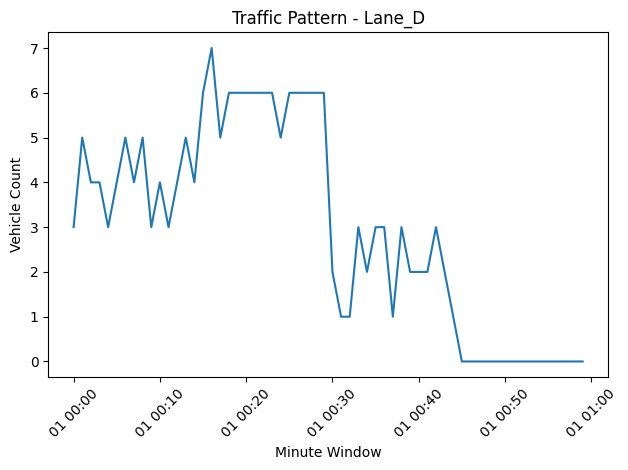

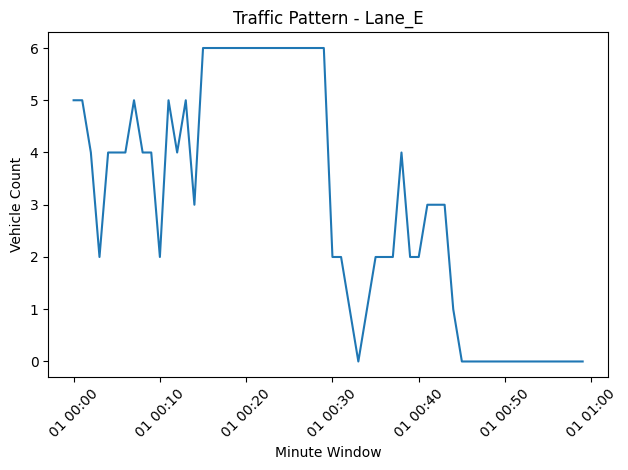

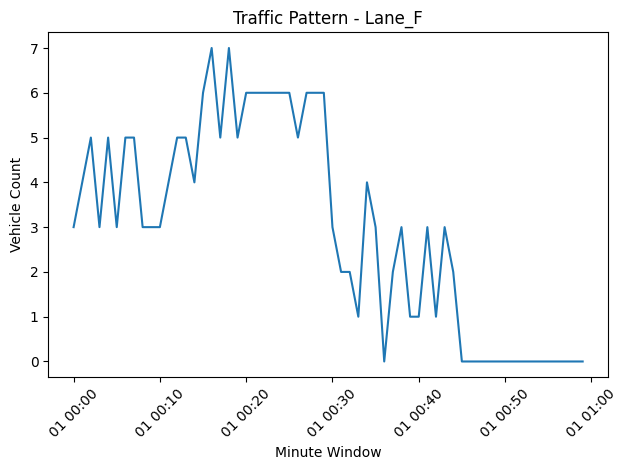

In [8]:
def plot_traffic_per_lane(df):
    lanes = df["Lane"].unique()

    for lane in lanes:
        lane_df = df[df["Lane"] == lane].sort_values("Minute_Window")

        plt.figure()
        plt.plot(lane_df["Minute_Window"], lane_df["Vehicle_Count"])
        plt.title(f"Traffic Pattern - {lane}")
        plt.xlabel("Minute Window")
        plt.ylabel("Vehicle Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
plot_traffic_per_lane(lane_counts)

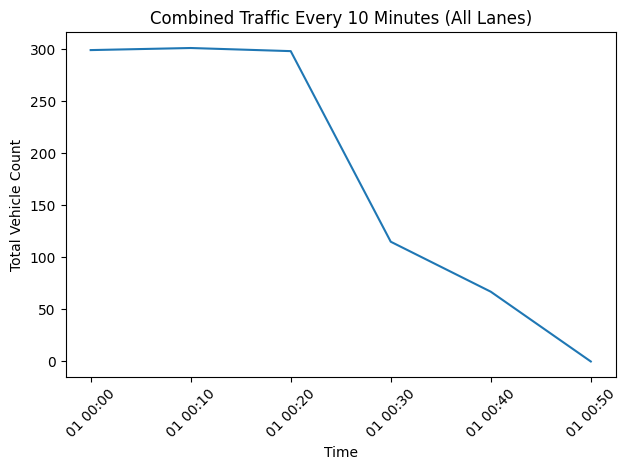

In [9]:
def plot_combined_traffic_10min(df):
    df = df.copy()
    df["Minute_Window"] = pd.to_datetime(df["Minute_Window"])

    # Combine all lanes
    combined = (
        df.groupby("Minute_Window")["Vehicle_Count"]
        .sum()
        .reset_index()
    )

    # Resample to 10-minute intervals
    combined_10min = (
        combined.set_index("Minute_Window")
        .resample("10min")
        .sum()
        .reset_index()
    )

    plt.figure()
    sns.lineplot(
        data=combined_10min,
        x="Minute_Window",
        y="Vehicle_Count"
    )

    plt.title("Combined Traffic Every 10 Minutes (All Lanes)")
    plt.xlabel("Time")
    plt.ylabel("Total Vehicle Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
plot_combined_traffic_10min(lane_counts)

In [10]:
percent_steps = [0, 25, 50, 75, 100]

lane_percentiles = (
    lane_counts
    .groupby("Lane")["Vehicle_Count"]
    .quantile([p / 100 for p in percent_steps], interpolation="nearest")
    .unstack()
)

lane_percentiles.columns = [f"P{p}" for p in percent_steps]

print("\nVehicle Count Percentiles per Lane:")
print(lane_percentiles)


Vehicle Count Percentiles per Lane:
        P0  P25  P50  P75  P100
Lane                           
Lane_A   0    0    3    5     6
Lane_B   0    0    3    5     7
Lane_C   0    0    3    5     7
Lane_D   0    1    3    5     7
Lane_E   0    0    3    5     6
Lane_F   0    0    3    5     7


#proportion of the label 0=low 1=high

In [11]:
print(lane_counts["Traffic_Label"].value_counts(normalize=True))

Traffic_Label
0    0.55
1    0.45
Name: proportion, dtype: float64


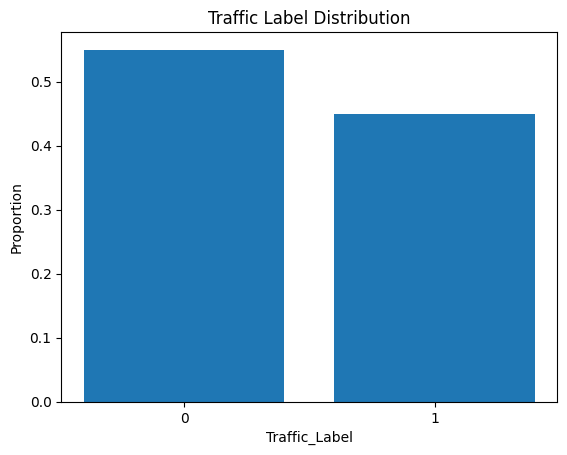

In [12]:
label_dist = lane_counts["Traffic_Label"].value_counts(normalize=True).sort_index()

plt.figure()
plt.bar(label_dist.index.astype(str), label_dist.values)
plt.xlabel("Traffic_Label")
plt.ylabel("Proportion")
plt.title("Traffic Label Distribution")
plt.show()

In [13]:
feature_cols = ["Vehicle_Count", "Delta",
                "Rolling_Mean_3", "Rolling_Mean_5"]

target_col = "Traffic_Label"

SEQ_LENGTH = 5


In [17]:
from tensorflow.keras.layers import Flatten
def build_rnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        SimpleRNN(8),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    return model


def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(8),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    return model


def build_cnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(16, 2, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=Adam(0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    return model



def build_ANN(input_shape):

    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(0.001),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [18]:
lanes = lane_counts["Lane"].unique()
MODEL_SAVE_PATH = r"C:\Users\BI2026\Model Without class weight"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

input_shape = (SEQ_LENGTH, len(feature_cols))

results = {
    "RNN": {"auc": [], "acc": []},
    "LSTM": {"auc": [], "acc": []},
    "CNN": {"auc": [], "acc": []},
    "ANN": {"auc": [], "acc": []}
}

# =============================
# CROSS-LANE VALIDATION
# =============================
for test_lane in lanes:

    print("\n==============================")
    print("TEST LANE :", test_lane)
    print("==============================")

    train_df = lane_counts[lane_counts["Lane"] != test_lane].copy()
    test_df  = lane_counts[lane_counts["Lane"] == test_lane].copy()

    scaler = MinMaxScaler()
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

    X_train, y_train = create_sequences_per_lane(
        train_df, feature_cols, target_col, SEQ_LENGTH
    )

    X_test, y_test = create_sequences_per_lane(
        test_df, feature_cols, target_col, SEQ_LENGTH
    )

    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)

    models = {
        "RNN": build_rnn(input_shape),
        "LSTM": build_lstm(input_shape),
        "CNN": build_cnn(input_shape),
        "ANN": build_ANN(input_shape)
    }

    for name, model in models.items():

        print("\nTraining:", name)

        history = model.fit(
            X_train,
            y_train,
            epochs=20,
            batch_size=8,
            validation_data=(X_test, y_test),
            shuffle=False,
            verbose=1
        )

        eval_results = model.evaluate(X_test, y_test, verbose=0)

        test_acc = eval_results[1]
        test_precision = eval_results[2]
        test_recall = eval_results[3]
        test_auc = eval_results[4]

        print("Accuracy :", round(test_acc,4))
        print("Precision:", round(test_precision,4))
        print("Recall   :", round(test_recall,4))
        print("AUC      :", round(test_auc,4))

        results[name]["auc"].append(test_auc)
        results [name]["acc"].append(test_acc)

        # =============================
        # SAVE TRAINING CURVES
        # =============================
        plt.figure()
        plt.plot(history.history['accuracy'])
        plt.plot(history.history['val_accuracy'])
        plt.title(f'{name} Accuracy - Test {test_lane}')
        plt.legend(['Train', 'Validation'])
        plt.savefig(os.path.join(
            MODEL_SAVE_PATH,
            f"{name}_{test_lane}_accuracy.png"
        ))
        plt.close()

        plt.figure()
        plt.plot(history.history['loss'])
        plt.plot(history.history['val_loss'])
        plt.title(f'{name} Loss - Test {test_lane}')
        plt.legend(['Train', 'Validation'])
        plt.savefig(os.path.join(
            MODEL_SAVE_PATH,
            f"{name}_{test_lane}_loss.png"
        ))
        plt.close()


TEST LANE : Lane_A
X_train: (275, 5, 4)
X_test : (55, 5, 4)

Training: RNN
Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3855 - auc: 0.1098 - loss: 0.9230 - precision: 0.3962 - recall: 0.8957 - val_accuracy: 0.4000 - val_auc: 0.0792 - val_loss: 0.8809 - val_precision: 0.4000 - val_recall: 1.0000
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4182 - auc: 0.2090 - loss: 0.8020 - precision: 0.4164 - recall: 0.9739 - val_accuracy: 0.4364 - val_auc: 0.2996 - val_loss: 0.7593 - val_precision: 0.4151 - val_recall: 1.0000
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4909 - auc: 0.5656 - loss: 0.7079 - precision: 0.4486 - recall: 0.9478 - val_accuracy: 0.6909 - val_auc: 0.8416 - val_loss: 0.6672 - val_precision: 0.5641 - val_recall: 1.0000
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7455 - auc: 0.8183 - loss: 0.6444 - precision: 0.6510 - recall: 0.8435 - val_accuracy: 0.9091 - val_auc: 0.9435 - val_loss: 0.6121 - val_pr

In [19]:
summary = {}

print("\n===== CROSS-LANE PERFORMANCE SUMMARY =====")

for model_name, metrics in results.items():
    mean_auc = np.mean(metrics["auc"])
    std_auc  = np.std(metrics["auc"])

    mean_acc = np.mean(metrics["acc"])
    std_acc  = np.std(metrics["acc"])

    summary[model_name] = {
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "mean_acc": mean_acc,
        "std_acc": std_acc
    }

    print(
        f"{model_name:5s} | "
        f"AUC: {mean_auc:.4f} ± {std_auc:.4f} | "
        f"ACC: {mean_acc:.4f} ± {std_acc:.4f}"
    )


===== CROSS-LANE PERFORMANCE SUMMARY =====
RNN   | AUC: 0.9228 ± 0.0322 | ACC: 0.8788 ± 0.0326
LSTM  | AUC: 0.9203 ± 0.0299 | ACC: 0.8758 ± 0.0194
CNN   | AUC: 0.9314 ± 0.0303 | ACC: 0.8697 ± 0.0529
ANN   | AUC: 0.9424 ± 0.0209 | ACC: 0.8848 ± 0.0250


In [ ]:
best_model_name = max(
    summary.keys(),
    key=lambda m: (
        (summary[m]["mean_auc"] - summary[m]["std_auc"]) +
        (summary[m]["mean_acc"] - summary[m]["std_acc"])
    )
)

print("BEST MODEL (Consistent AUC + ACC):", best_model_name)

In [ ]:

# FINAL TRAINING (ALL LANES)

scaler = MinMaxScaler()
lane_counts[feature_cols] = scaler.fit_transform(lane_counts[feature_cols])

X_all, y_all = create_sequences_per_lane(
    lane_counts, feature_cols, target_col, SEQ_LENGTH
)

if best_model_name == "RNN":
    final_model = build_rnn(input_shape)
elif best_model_name == "LSTM":
    final_model = build_lstm(input_shape)
else:
    final_model = build_cnn(input_shape)

final_model.fit(
    X_all,
    y_all,
    epochs=20,
    batch_size=8,
    shuffle=False,
    verbose=1
)

In [ ]:
MODEL_FINAL_PATH = os.path.join(
    MODEL_SAVE_PATH,
    f"best_{best_model_name}_percentile50.h5"
)

SCALER_PATH = os.path.join(
    MODEL_SAVE_PATH,
    "scaler.save"
)

final_model.save(MODEL_FINAL_PATH)
joblib.dump(scaler, SCALER_PATH)

print("Final model saved to:", MODEL_FINAL_PATH)
print("Scaler saved to:", SCALER_PATH)